In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/jessevent/all-crypto-currencies/crypto-markets.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime 
import scipy.stats as stats
%matplotlib inline

In [3]:
import warnings 
warnings.filterwarnings('ignore')

In [4]:
# Data Collection

In [5]:
crypto = pd.read_csv('/kaggle/input/datasets/jessevent/all-crypto-currencies/crypto-markets.csv')
crypto.head()

,slug,symbol,name,date,ranknow,open,high,low,close,volume,market,close_ratio,spread
0,bitcoin,BTC,Bitcoin,2013-04-28,1,135.30,135.98,132.10,134.21,0.0,1.488567e+09,0.5438,3.88
1,bitcoin,BTC,Bitcoin,2013-04-29,1,134.44,147.49,134.00,144.54,0.0,1.603769e+09,0.7813,13.49
2,bitcoin,BTC,Bitcoin,2013-04-30,1,144.00,146.93,134.05,139.00,0.0,1.542813e+09,0.3843,12.88
3,bitcoin,BTC,Bitcoin,2013-05-01,1,139.00,139.89,107.72,116.99,0.0,1.298955e+09,0.2882,32.17
4,bitcoin,BTC,Bitcoin,2013-05-02,1,116.38,125.60,92.28,105.21,0.0,1.168517e+09,0.3881,33.32


In [6]:
crypto.columns

Index(['slug', 'symbol', 'name', 'date', 'ranknow', 'open', 'high', 'low',
       'close', 'volume', 'market', 'close_ratio', 'spread'],
      dtype='object')

In [7]:
crypto['date'] = pd.to_datetime(crypto.date)

In [8]:
# Data Understanding

In [9]:
print(crypto.shape)
print('---------------------------')
print(crypto.nunique())
print('---------------------------')
print(crypto.info())
print('---------------------------')
print(crypto.describe())
print('---------------------------')
print(crypto.isnull().sum())
print('---------------------------')
print(crypto.duplicated().sum())

(942297, 13)
---------------------------
slug             2071
symbol           2005
name             2071
date             2043
ranknow          2068
open           266140
high           269676
low            263008
close          265887
volume         300528
market         660996
close_ratio     10022
spread          12454
dtype: int64
---------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 942297 entries, 0 to 942296
Data columns (total 13 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   slug         942297 non-null  object        
 1   symbol       942297 non-null  object        
 2   name         942297 non-null  object        
 3   date         942297 non-null  datetime64[ns]
 4   ranknow      942297 non-null  int64         
 5   open         942297 non-null  float64       
 6   high         942297 non-null  float64       
 7   low          942297 non-null  float64       
 8   close        942

In [10]:
# Data Cleaning

In [11]:
(crypto[['open','high','low','close']] < 0).sum()

open     0
high     0
low      0
close    0
dtype: int64

In [12]:
(crypto['volume']<0).sum()

np.int64(0)

In [13]:
print((crypto['high'] < crypto['low']).sum())
print(((crypto['close'] < crypto['low']) | (crypto['close'] > crypto['high'])).sum())

0
25


In [14]:
crypto.loc[
    (crypto['close'] < crypto['low']) | (crypto['close'] > crypto['high']),
    ['date', 'open', 'high', 'low', 'close', 'volume']
]

,date,open,high,low,close,volume
216012,2015-11-22,6.500000e-09,6.600000e-09,5.800000e-09,5.700000e-09,22.0
216039,2015-12-19,6.500000e-09,7.900000e-09,5.400000e-09,5.300000e-09,10.0
216057,2016-01-06,6.800000e-09,7.300000e-09,6.200000e-09,6.100000e-09,13.0
216069,2016-01-18,6.200000e-09,6.400000e-09,5.900000e-09,5.800000e-09,8.0
216242,2016-07-09,8.900000e-09,1.000000e-08,8.300000e-09,8.200000e-09,1.0
216244,2016-07-11,1.000000e-08,1.000000e-08,8.500000e-09,8.400000e-09,0.0
216252,2016-07-19,8.500000e-09,9.000000e-09,7.400000e-09,7.300000e-09,12.0
216320,2016-09-25,4.200000e-09,4.700000e-09,4.000000e-09,3.900000e-09,41.0
216324,2016-09-29,4.300000e-09,4.800000e-09,3.600000e-09,3.500000e-09,4.0
216328,2016-10-03,4.200000e-09,4.700000e-09,4.100000e-09,4.000000e-09,2.0


In [15]:
crypto[['close','volume','spread','market']].describe()

,close,volume,spread,market
count,9.422970e+05,9.422970e+05,9.422970e+05,9.422970e+05
mean,3.461018e+02,8.720383e+06,1.123400e+02,1.725060e+08
std,1.309822e+04,1.839802e+08,6.783713e+03,3.575590e+09
min,2.000000e-10,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.314000e-03,1.750000e+02,0.000000e+00,2.958100e+04
50%,2.389200e-02,4.278000e+03,0.000000e+00,5.227960e+05
75%,2.259340e-01,1.190900e+05,3.000000e-02,6.874647e+06
max,2.300740e+06,2.384090e+10,1.770563e+06,3.265025e+11


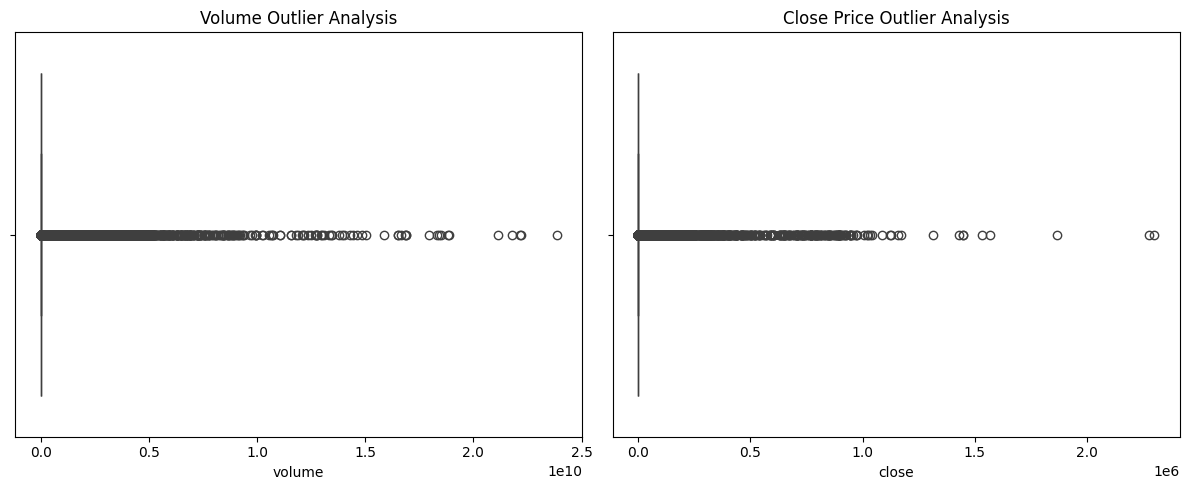

In [16]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x=crypto['volume'])
plt.title('Volume Outlier Analysis')

plt.subplot(1,2,2)
sns.boxplot(x=crypto['close'])
plt.title('Close Price Outlier Analysis')

plt.tight_layout()
plt.show()

In [17]:
# Feature Engineering

In [18]:
crypto.head()

,slug,symbol,name,date,ranknow,open,high,low,close,volume,market,close_ratio,spread
0,bitcoin,BTC,Bitcoin,2013-04-28,1,135.30,135.98,132.10,134.21,0.0,1.488567e+09,0.5438,3.88
1,bitcoin,BTC,Bitcoin,2013-04-29,1,134.44,147.49,134.00,144.54,0.0,1.603769e+09,0.7813,13.49
2,bitcoin,BTC,Bitcoin,2013-04-30,1,144.00,146.93,134.05,139.00,0.0,1.542813e+09,0.3843,12.88
3,bitcoin,BTC,Bitcoin,2013-05-01,1,139.00,139.89,107.72,116.99,0.0,1.298955e+09,0.2882,32.17
4,bitcoin,BTC,Bitcoin,2013-05-02,1,116.38,125.60,92.28,105.21,0.0,1.168517e+09,0.3881,33.32


In [19]:
crypto['daily_return'] = crypto.groupby('name')['close'].pct_change()
crypto['price_range'] = crypto['high'] - crypto['low']
crypto['year'] = crypto['date'].dt.year
crypto['month'] = crypto['date'].dt.month
crypto['ma_30']= crypto['close'].rolling(30).mean()

In [20]:
top20 = crypto.groupby('name')['market'].max().nlargest(20).index
crypto_top20 = crypto[crypto['name'].isin(top20)]

In [21]:
crypto_top20 = crypto_top20.sort_values(['name','date'])

In [22]:
crypto.tail()

,slug,symbol,name,date,ranknow,open,high,low,close,volume,market,close_ratio,spread,daily_return,price_range,year,month,ma_30
942292,project-x,NANOX,Project-X,2018-11-26,1727,22424.60,23049.30,17607.50,20724.80,143.0,1622.0,0.5728,5441.80,-0.076048,5441.80,2018,11,32410.350000
942293,project-x,NANOX,Project-X,2018-11-27,1727,20711.90,23742.10,19292.90,23298.70,637.0,1823.0,0.9003,4449.20,0.124194,4449.20,2018,11,31955.236667
942294,project-x,NANOX,Project-X,2018-11-28,1727,23320.90,25235.10,19888.10,24442.70,49.0,1913.0,0.8518,5347.00,0.049101,5347.00,2018,11,31612.110000
942295,project-x,NANOX,Project-X,2018-11-29,1727,24543.53,24582.47,21457.95,22839.44,153.0,1788.0,0.4421,3124.52,-0.065593,3124.52,2018,11,31242.261333
942296,project-x,NANOX,Project-X,2018-11-30,1727,22872.09,23086.98,19040.91,21136.72,125.0,1654.0,0.5180,4046.07,-0.074552,4046.07,2018,11,30586.885333


In [23]:
# Univirate Analysis

In [24]:
crypto['close'].describe()

count    9.422970e+05
mean     3.461018e+02
std      1.309822e+04
min      2.000000e-10
25%      2.314000e-03
50%      2.389200e-02
75%      2.259340e-01
max      2.300740e+06
Name: close, dtype: float64

<Axes: xlabel='close', ylabel='Count'>

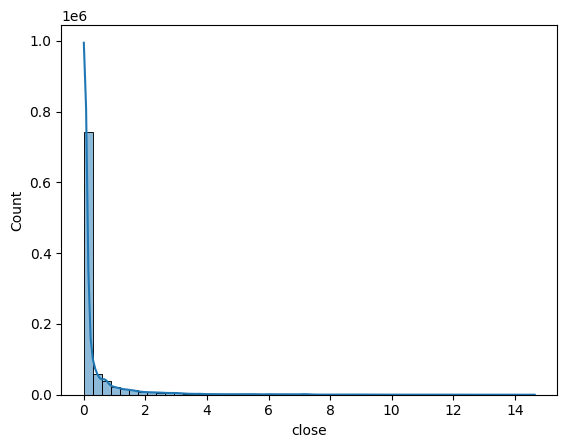

In [25]:
sns.histplot(np.log1p(crypto['close']), bins=50,kde=True)

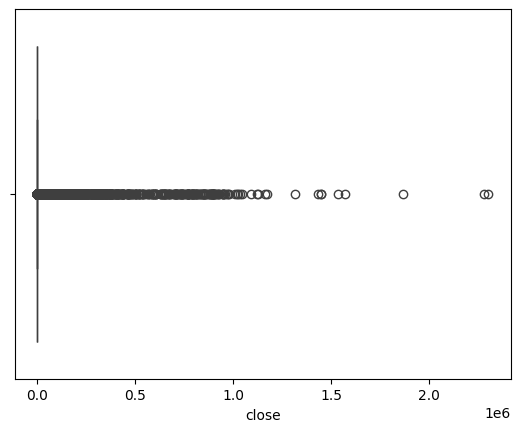

In [26]:

sns.boxplot(x=crypto['close'])
plt.show()

# Observations (Histogram + Boxplot of close)

***The histogram of the close price shows a highly right-skewed distribution, indicating that most cryptocurrency prices are concentrated at lower values while a small number of observations have extremely high prices. The boxplot further confirms the presence of numerous upper-end outliers. These outliers likely represent high-value cryptocurrencies and genuine market behavior rather than data errors. Therefore, the outliers were retained for further analysis.***

In [27]:
crypto['volume'].describe()

count    9.422970e+05
mean     8.720383e+06
std      1.839802e+08
min      0.000000e+00
25%      1.750000e+02
50%      4.278000e+03
75%      1.190900e+05
max      2.384090e+10
Name: volume, dtype: float64

<Axes: xlabel='volume', ylabel='Count'>

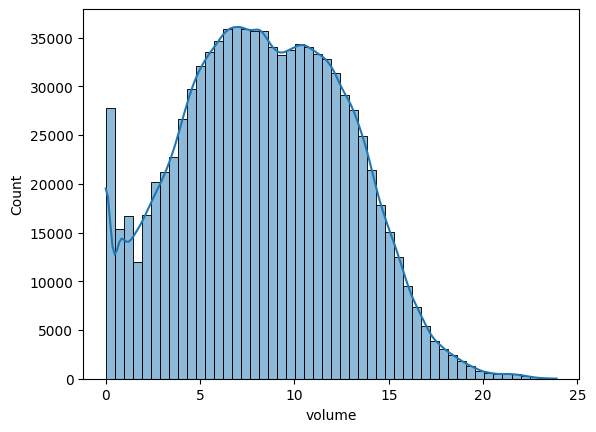

In [28]:
sns.histplot(np.log1p(crypto['volume']), bins=50,kde=True)

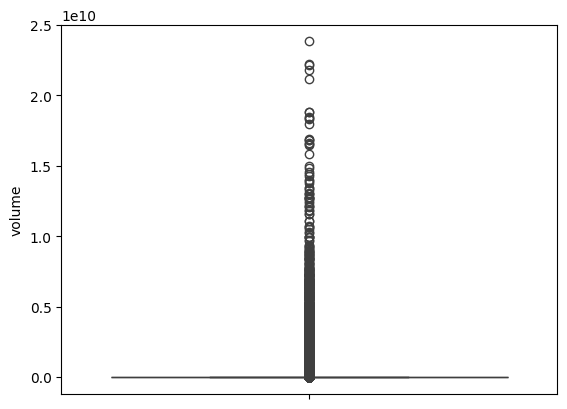

In [29]:
sns.boxplot(crypto['volume'])
plt.show()

# Observation (Histogram + Boxplot of volume)

***The histogram of the volume feature shows a positively skewed distribution, with most trading volumes concentrated in the lower to middle range and a gradual decline toward higher values. The boxplot indicates the presence of several high-volume outliers. These extreme values are expected in cryptocurrency markets, where a few coins experience significantly higher trading activity than others. Since these observations represent genuine market behavior rather than data-entry errors, the outliers were retained for analysis.**

In [30]:
crypto['market'].describe()

count    9.422970e+05
mean     1.725060e+08
std      3.575590e+09
min      0.000000e+00
25%      2.958100e+04
50%      5.227960e+05
75%      6.874647e+06
max      3.265025e+11
Name: market, dtype: float64

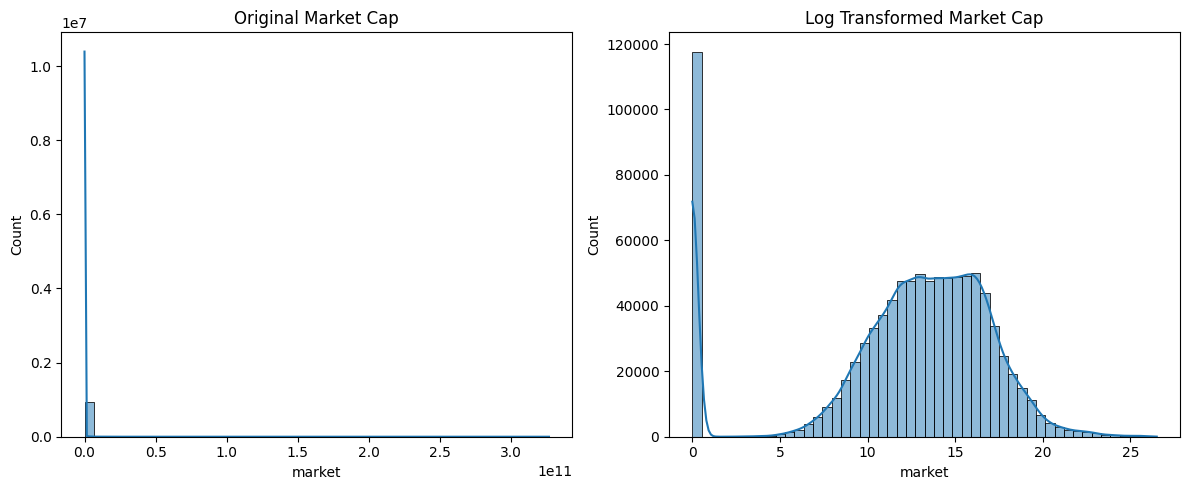

In [31]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(crypto['market'], bins=50, kde=True)
plt.title('Original Market Cap')

plt.subplot(1,2,2)
sns.histplot(np.log1p(crypto['market']), bins=50, kde=True)
plt.title('Log Transformed Market Cap')

plt.tight_layout()
plt.show()

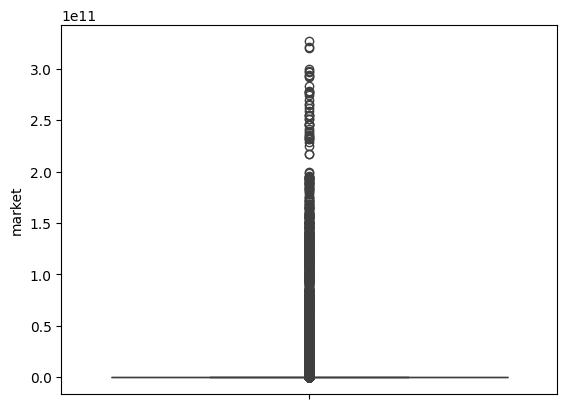

In [32]:
sns.boxplot(crypto['market'])
plt.show()

# Observations

***The distribution of the market feature is non-normal and positively skewed. The histogram shows that market capitalization values are concentrated in specific ranges, while a smaller number of observations have very high market capitalization values. The boxplot confirms the presence of several upper-end outliers. These outliers are expected in the cryptocurrency market, where a few major coins dominate the overall market capitalization. Therefore, the outliers were retained as they represent genuine market conditions rather than data errors.***

In [33]:
crypto['spread'].describe()

count    9.422970e+05
mean     1.123400e+02
std      6.783713e+03
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      3.000000e-02
max      1.770563e+06
Name: spread, dtype: float64

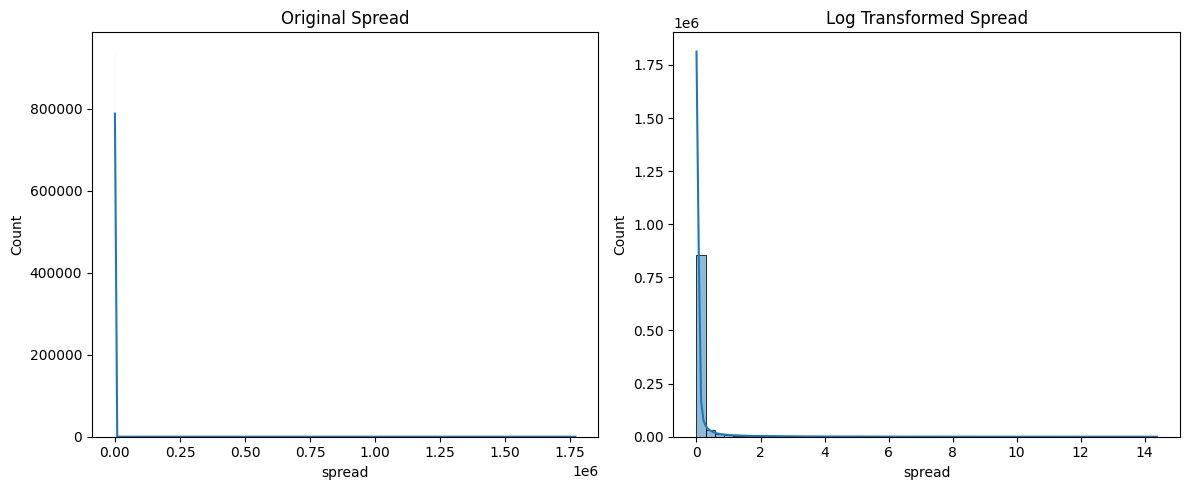

In [34]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(crypto['spread'], kde=True)
plt.title('Original Spread')

plt.subplot(1,2,2)
sns.histplot(np.log1p(crypto['spread']), bins=50, kde=True)
plt.title('Log Transformed Spread')

plt.tight_layout()
plt.show()

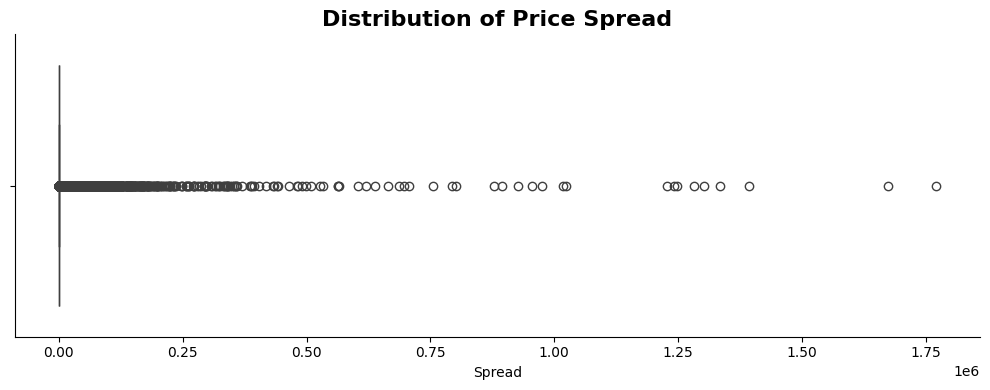

In [35]:
plt.figure(figsize=(10,4))

sns.boxplot(x=crypto['spread'])

plt.title(
    'Distribution of Price Spread',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Spread')

sns.despine()

plt.tight_layout()
plt.show()

# Observation

***The distribution of the spread feature is highly right-skewed, with most observations concentrated near zero, indicating that daily price ranges are generally small for most cryptocurrencies. The boxplot reveals the presence of several upper-end outliers, suggesting that a limited number of observations experienced unusually large price fluctuations. These outliers likely represent periods of high market volatility and were retained as they reflect genuine market behavior rather than data errors***

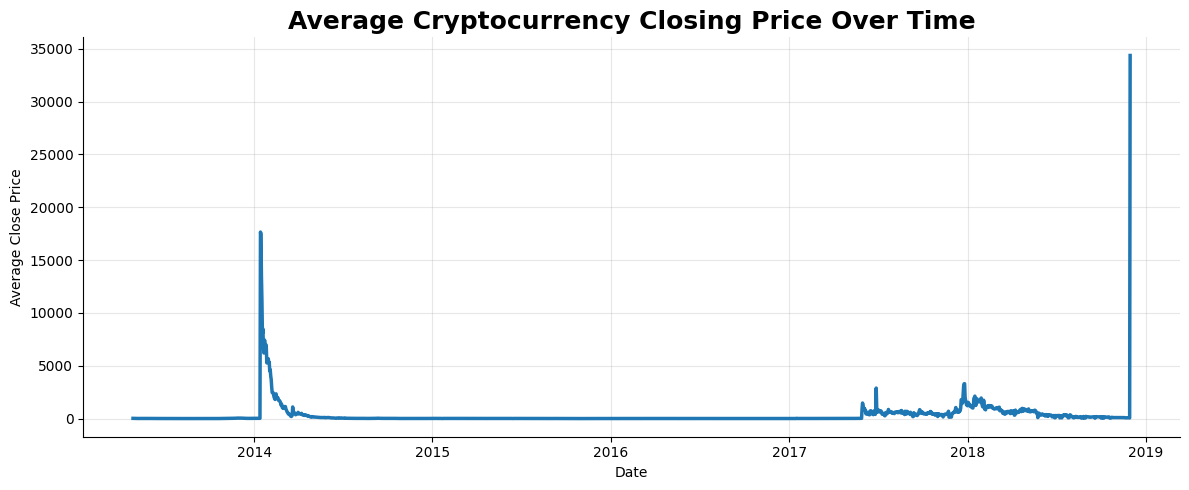

In [36]:
close_trend = (
    crypto.groupby('date')['close']
          .mean()
)

plt.figure(figsize=(12,5))

plt.plot(
    close_trend.index,
    close_trend.values,
    linewidth=2.5
)

plt.title(
    'Average Cryptocurrency Closing Price Over Time',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Date')
plt.ylabel('Average Close Price')

plt.grid(alpha=0.3)

sns.despine()

plt.tight_layout()
plt.show()

**The cryptocurrency market exhibits extremely high volatility with significant price spikes and crashes. The period around 2017 - 2018 shows the highest market activity and price surges.The presence of numerous outliers and large fluctuations indicates that cryptocurrency investents carry substantial risk while also offering opportunities for high returns**

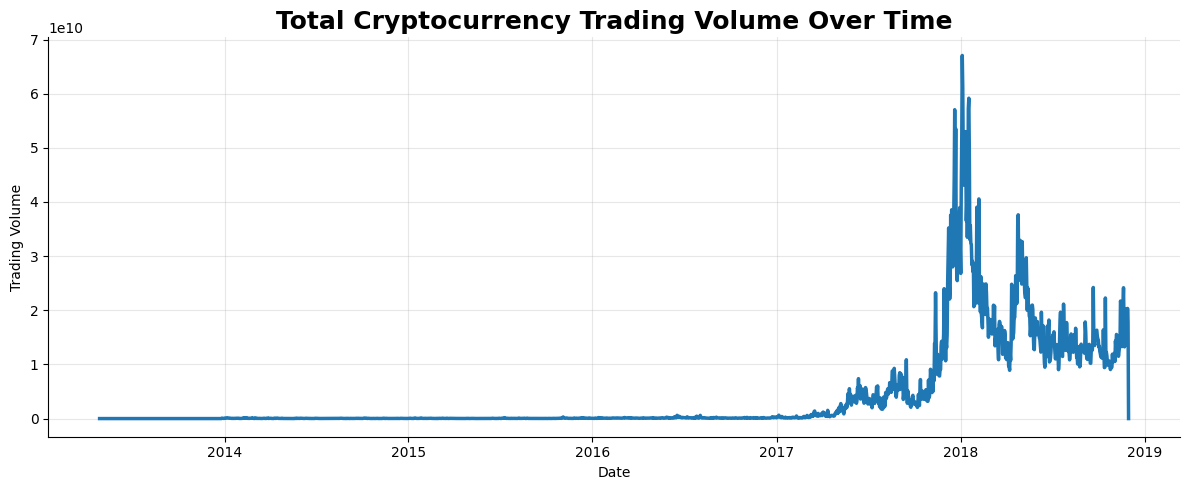

In [37]:
volume_trend = (
    crypto.groupby('date')['volume']
          .sum()
)

plt.figure(figsize=(12,5))

plt.plot(
    volume_trend.index,
    volume_trend.values,
    linewidth=2.5
)

plt.title(
    'Total Cryptocurrency Trading Volume Over Time',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Date')
plt.ylabel('Trading Volume')

plt.grid(alpha=0.3)

sns.despine()

plt.tight_layout()
plt.show()

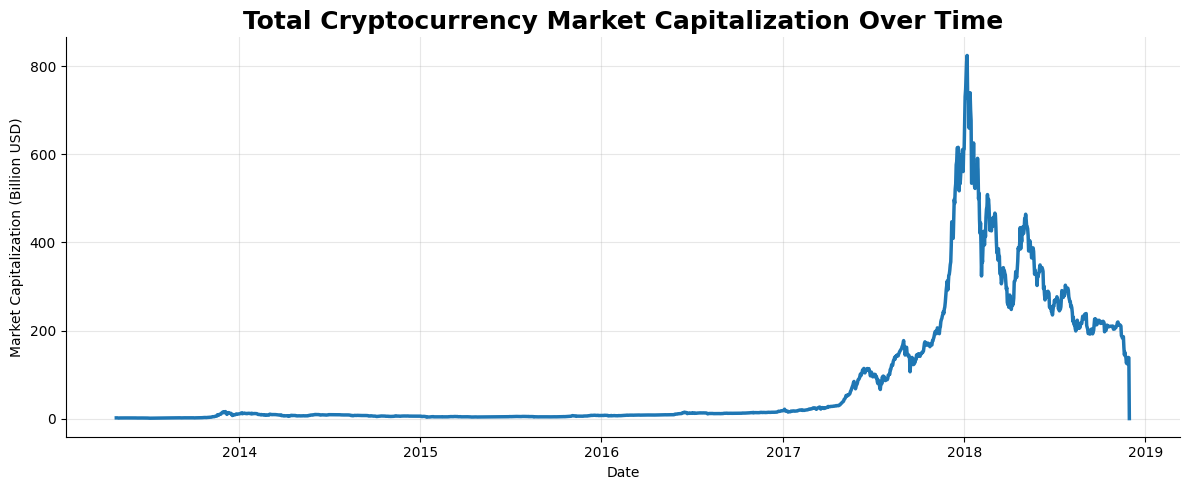

In [38]:
market_trend = (
    crypto.groupby('date')['market']
          .sum()
)

plt.figure(figsize=(12,5))

plt.plot(
    market_trend.index,
    market_trend.values / 1e9,
    linewidth=2.5
)

plt.title(
    'Total Cryptocurrency Market Capitalization Over Time',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Date')
plt.ylabel('Market Capitalization (Billion USD)')

plt.grid(alpha=0.3)

sns.despine()

plt.tight_layout()
plt.show()

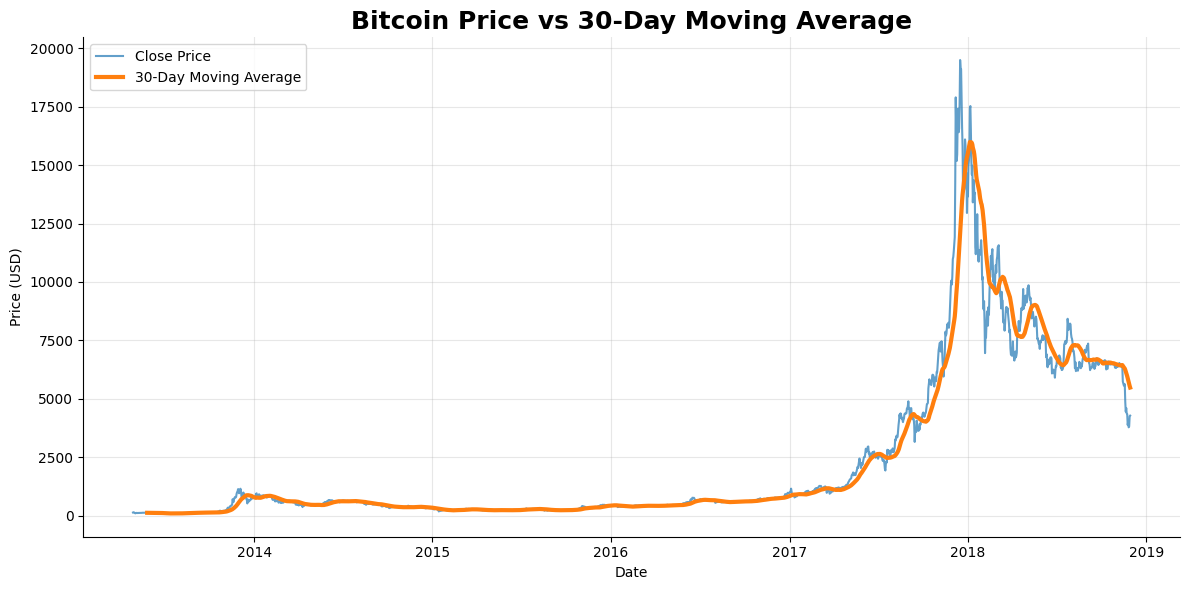

In [39]:
btc = crypto[crypto['name'] == 'Bitcoin'].copy()

btc['ma_30'] = btc['close'].rolling(30).mean()

plt.figure(figsize=(12,6))

plt.plot(
    btc['date'],
    btc['close'],
    label='Close Price',
    linewidth=1.5,
    alpha=0.7
)

plt.plot(
    btc['date'],
    btc['ma_30'],
    label='30-Day Moving Average',
    linewidth=3
)

plt.title(
    'Bitcoin Price vs 30-Day Moving Average',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Date')
plt.ylabel('Price (USD)')

plt.grid(alpha=0.3)

plt.legend()

sns.despine()

plt.tight_layout()
plt.show()

In [40]:
# Volatility Analysis

<Axes: xlabel='spread', ylabel='Count'>

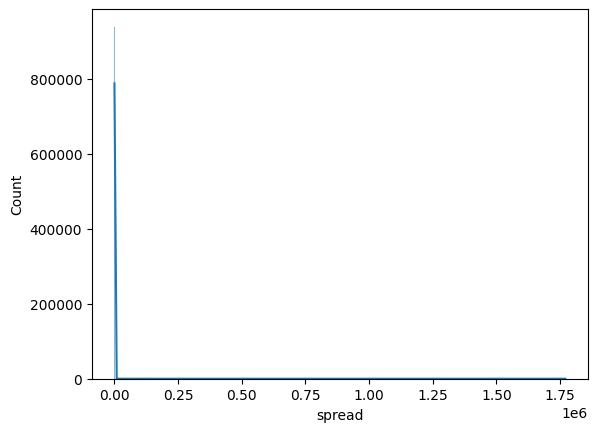

In [41]:
sns.histplot(crypto['spread'],kde=True)


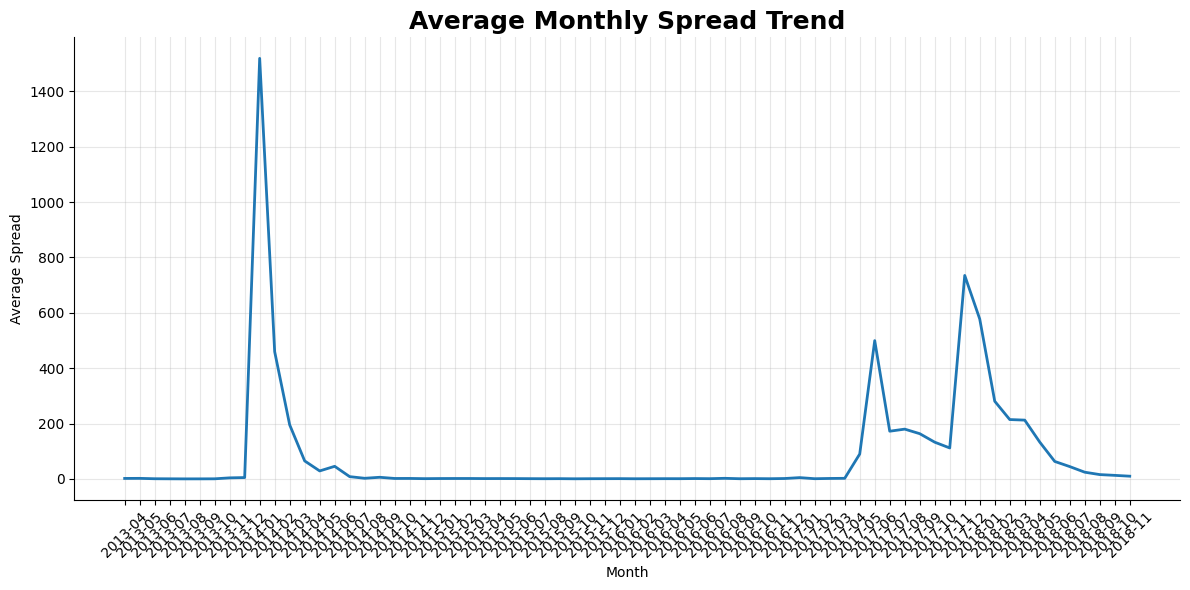

In [42]:
crypto['year_month'] = crypto['date'].dt.to_period('M')

monthly_spread = (
    crypto.groupby('year_month')['spread']
          .mean()
)

plt.figure(figsize=(12,6))

plt.plot(
    monthly_spread.index.astype(str),
    monthly_spread.values,
    linewidth=2
)

plt.title(
    'Average Monthly Spread Trend',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Month')
plt.ylabel('Average Spread')

plt.grid(alpha=0.3)

plt.xticks(rotation=45)

sns.despine()

plt.tight_layout()
plt.show()

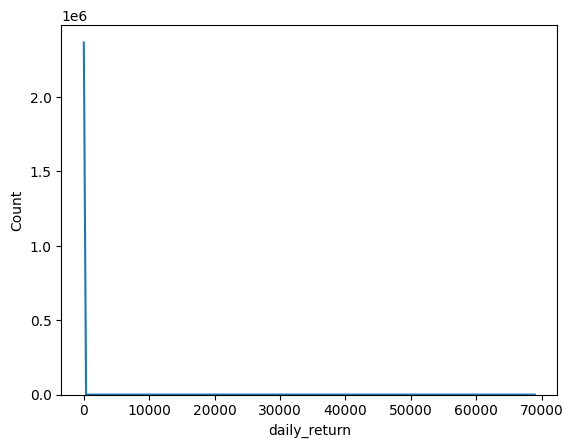

In [43]:
sns.histplot(crypto['daily_return'].dropna(), kde=True)
plt.show()

In [44]:
crypto.nlargest(10, 'daily_return')[['name','date','daily_return']]

,name,date,daily_return
68060,Veritaseum,2017-06-12,68933.911243
479932,AllSafe,2017-06-23,34513.333333
900159,STEX,2017-06-13,28026.692308
420140,Global Cryptocurrency,2017-03-20,17488.700000
930693,Alphabit,2017-07-04,2599.157109
273344,Etheroll,2017-06-12,969.564837
718599,Dix Asset,2017-05-08,849.000000
913654,Bubble,2017-09-18,785.797101
529600,B3Coin,2018-01-14,722.202797
415192,Veros,2018-04-26,608.460674


In [45]:
crypto.nsmallest(10, 'daily_return')[['name','date','daily_return']]

,name,date,daily_return
900158,STEX,2017-06-11,-0.999943
68059,Veritaseum,2017-06-11,-0.999893
857331,Coimatic 3.0,2017-11-19,-0.999879
420785,Breakout,2016-07-11,-0.999863
231613,Xaurum,2016-08-22,-0.999853
718598,Dix Asset,2017-04-25,-0.999697
192883,CasinoCoin,2018-01-17,-0.999346
608153,Helleniccoin,2015-07-22,-0.999330
885652,ERC20,2018-06-16,-0.998808
273343,Etheroll,2017-06-10,-0.998378


In [46]:
crypto.groupby('name')['daily_return'].mean().sort_values(ascending=False)

name
Veritaseum               127.895831
STEX                      53.209154
AllSafe                   45.880842
Global Cryptocurrency     28.193698
Etheera                    4.033476
                            ...    
CoinToGo                  -0.077828
VisionX                   -0.081954
BitNautic Token           -0.097512
Provoco Token             -0.104828
BEAT                      -0.282881
Name: daily_return, Length: 2071, dtype: float64

In [47]:
crypto['volatility_30d'] = (
    crypto.groupby('name')['daily_return']
      .rolling(30)
      .std()
      .reset_index(level=0, drop=True)
)

In [48]:
crypto.groupby('name')['volatility_30d'].mean().sort_values(ascending=False)

name
AllSafe                  260.188849
Veritaseum                98.809138
STEX                      61.896386
Alphabit                  17.485876
Global Cryptocurrency     16.373889
                            ...    
Sub Invest                      NaN
TV-TWO                          NaN
VestChain                       NaN
Vites                           NaN
WeShow Token                    NaN
Name: volatility_30d, Length: 2071, dtype: float64

In [49]:
crypto.groupby('name')['volatility_30d'].mean().sort_values()

name
Tether                  0.003882
USD Coin                0.005739
Paxos Standard Token    0.005987
Gemini Dollar           0.007717
nUSD                    0.007995
                          ...   
Sub Invest                   NaN
TV-TWO                       NaN
VestChain                    NaN
Vites                        NaN
WeShow Token                 NaN
Name: volatility_30d, Length: 2071, dtype: float64

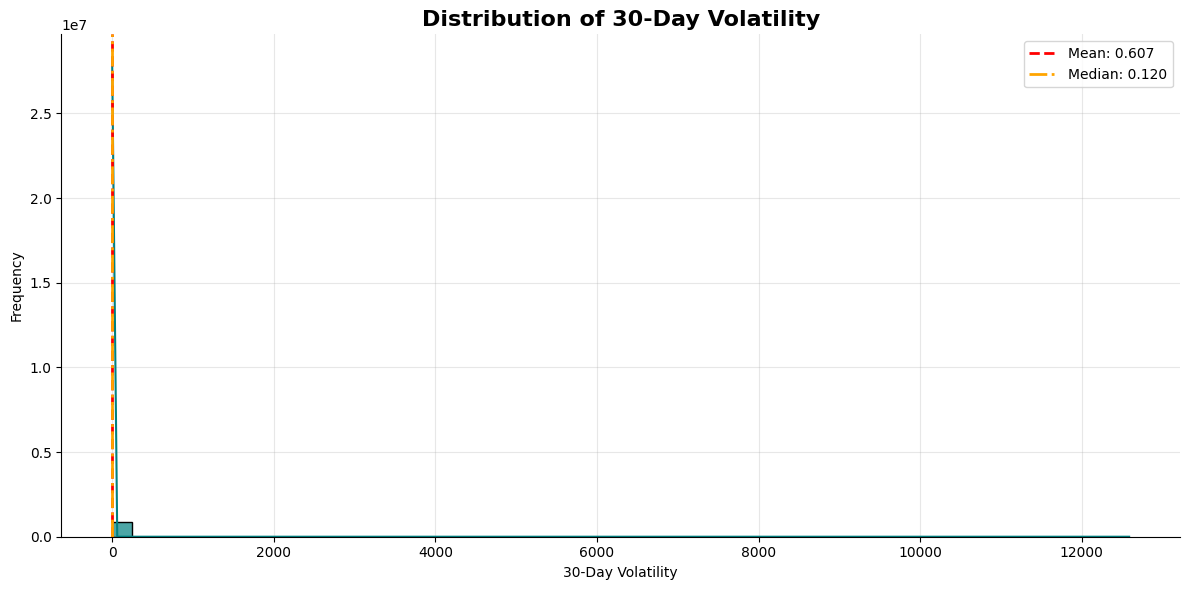

In [50]:
plt.figure(figsize=(12,6))

sns.histplot(
    crypto['volatility_30d'].dropna(),
    bins=50,
    kde=True,
    color='teal',
    edgecolor='black',
    alpha=0.7
)

plt.axvline(
    crypto['volatility_30d'].mean(),
    color='red',
    linestyle='--',
    linewidth=2,
    label=f"Mean: {crypto['volatility_30d'].mean():.3f}"
)

plt.axvline(
    crypto['volatility_30d'].median(),
    color='orange',
    linestyle='-.',
    linewidth=2,
    label=f"Median: {crypto['volatility_30d'].median():.3f}"
)

plt.title(
    'Distribution of 30-Day Volatility',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('30-Day Volatility')
plt.ylabel('Frequency')

plt.grid(alpha=0.3)
plt.legend()

sns.despine()

plt.tight_layout()
plt.show()

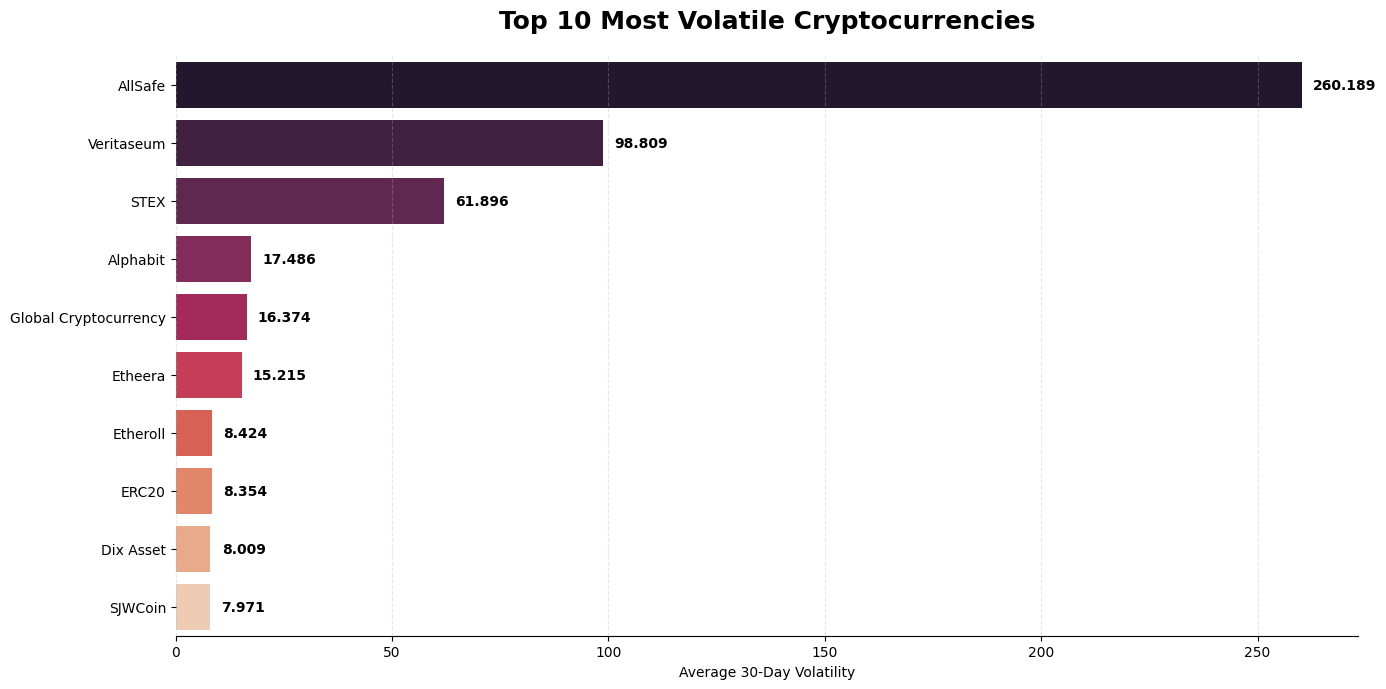

In [51]:
vol = (
    crypto.groupby('name')['volatility_30d']
          .mean()
          .sort_values(ascending=False)
          .head(10)
)

plt.figure(figsize=(14,7))

ax = sns.barplot(
    x=vol.values,
    y=vol.index,
    hue=vol.index,
    palette='rocket',
    legend=False
)

plt.title(
    'Top 10 Most Volatile Cryptocurrencies',
    fontsize=18,
    fontweight='bold',
    pad=20
)

plt.xlabel('Average 30-Day Volatility')
plt.ylabel('')

for i, v in enumerate(vol.values):
    ax.text(
        v + vol.max()*0.01,
        i,
        f'{v:.3f}',
        va='center',
        fontweight='bold'
    )

plt.grid(axis='x', linestyle='--', alpha=0.3)

sns.despine(left=True)

plt.tight_layout()
plt.show()

In [52]:
# Correlation Analysis

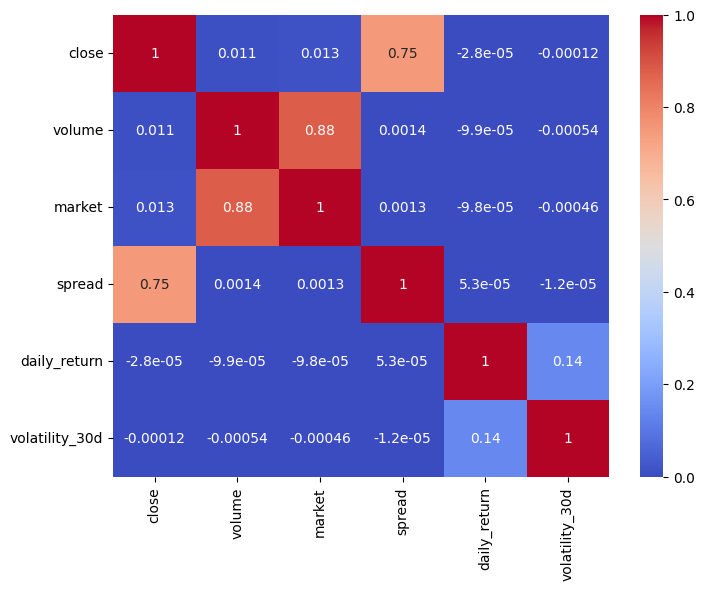

In [53]:
corr_cols = ['close','volume','market','spread','daily_return','volatility_30d']

corr = crypto[corr_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [54]:
from scipy.stats import shapiro

sample = crypto['daily_return'].dropna().sample(5000, random_state=42)

stat, p = shapiro(sample)

print("p-value:", p)

p-value: 6.817922586011752e-85


In [55]:
from scipy.stats import zscore

crypto['return_zscore'] = zscore(crypto['daily_return'].fillna(0))

outliers = crypto[abs(crypto['return_zscore']) > 3]

print("Outliers:", len(outliers))

Outliers: 18


In [56]:
crypto['year'] = crypto['date'].dt.year

yearly_returns = crypto.groupby('year')['daily_return'].mean()

print(yearly_returns)

year
2013    0.057238
2014    0.033461
2015    0.032139
2016    0.047431
2017    0.798156
2018    0.015641
Name: daily_return, dtype: float64


In [57]:
# Visualization 

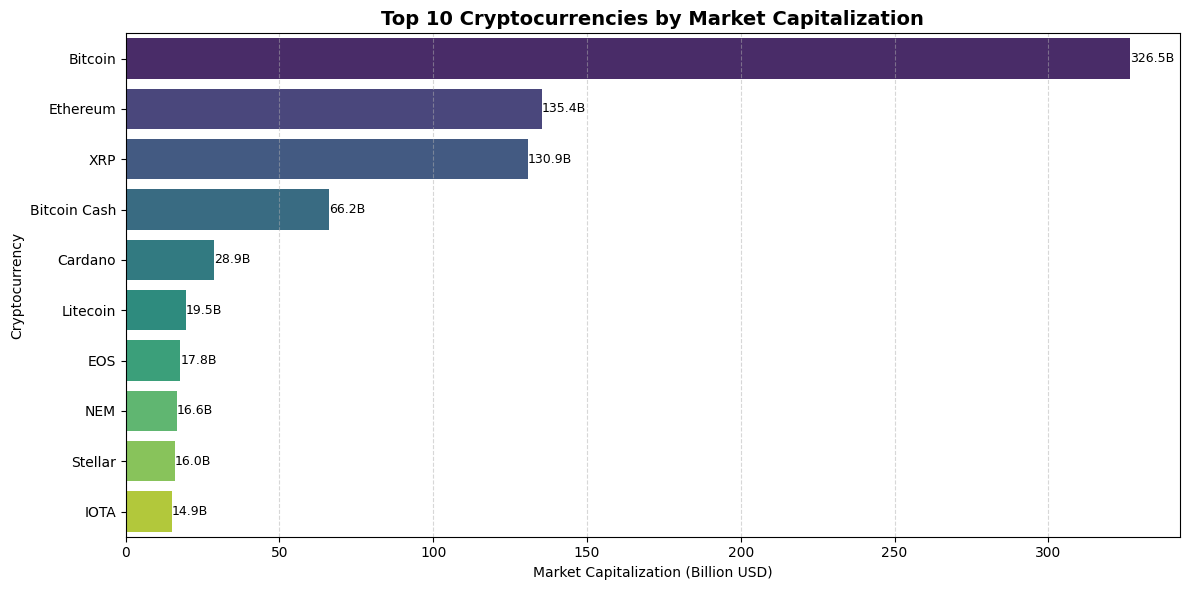

In [58]:
top_market = (
    crypto.groupby('name')['market']
      .max()
      .sort_values(ascending=False)
      .head(10) / 1e9
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top_market.values,
    y=top_market.index,
    hue=top_market.index,
    palette='viridis',
    legend=False
)

plt.title('Top 10 Cryptocurrencies by Market Capitalization', fontsize=14, fontweight='bold')
plt.xlabel('Market Capitalization (Billion USD)')
plt.ylabel('Cryptocurrency')

for i, v in enumerate(top_market.values):
    ax.text(
        v,
        i,
        f'{v:,.1f}B',
        va='center',
        ha='left',
        fontsize=9
    )

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

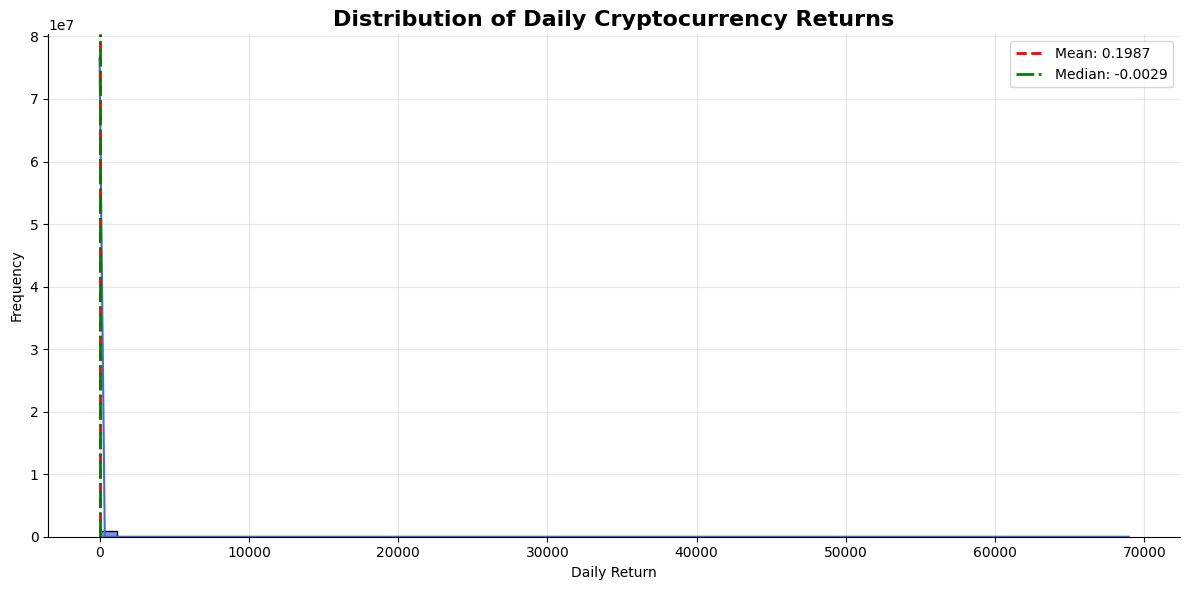

In [59]:
plt.figure(figsize=(12,6))

sns.histplot(
    crypto['daily_return'].dropna(),
    bins=60,
    kde=True,
    color='royalblue',
    edgecolor='black',
    alpha=0.7
)

plt.axvline(
    crypto['daily_return'].mean(),
    color='red',
    linestyle='--',
    linewidth=2,
    label=f"Mean: {crypto['daily_return'].mean():.4f}"
)

plt.axvline(
    crypto['daily_return'].median(),
    color='green',
    linestyle='-.',
    linewidth=2,
    label=f"Median: {crypto['daily_return'].median():.4f}"
)

plt.title(
    'Distribution of Daily Cryptocurrency Returns',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Daily Return')
plt.ylabel('Frequency')

plt.grid(alpha=0.3)
plt.legend()

sns.despine()

plt.tight_layout()
plt.show()

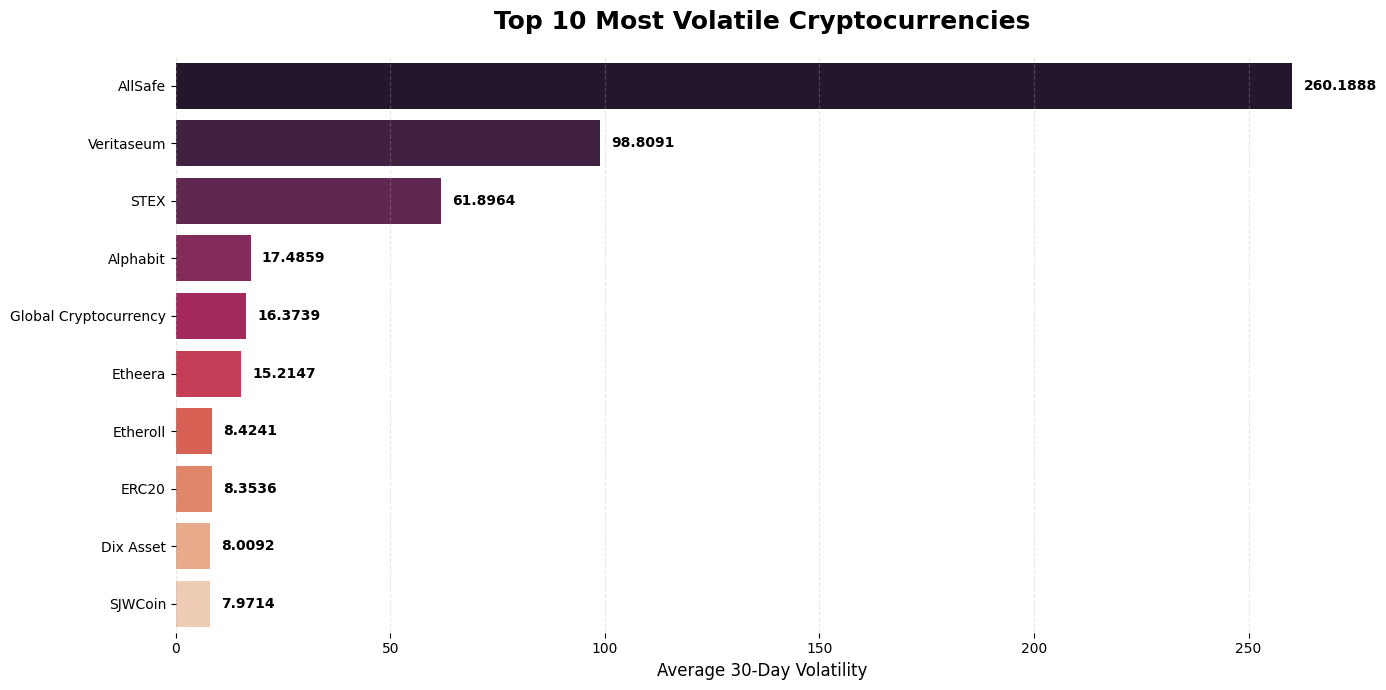

In [60]:
vol = (
    crypto.groupby('name')['volatility_30d']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(14,7))

ax = sns.barplot(
    x=vol.values,
    y=vol.index,
    hue=vol.index,
    palette='rocket',
    legend=False
)

plt.title(
    'Top 10 Most Volatile Cryptocurrencies',
    fontsize=18,
    fontweight='bold',
    pad=20
)

plt.xlabel('Average 30-Day Volatility', fontsize=12)
plt.ylabel('')

for i, v in enumerate(vol.values):
    ax.text(
        v + vol.max()*0.01,
        i,
        f'{v:.4f}',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

plt.grid(axis='x', linestyle='--', alpha=0.3)

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

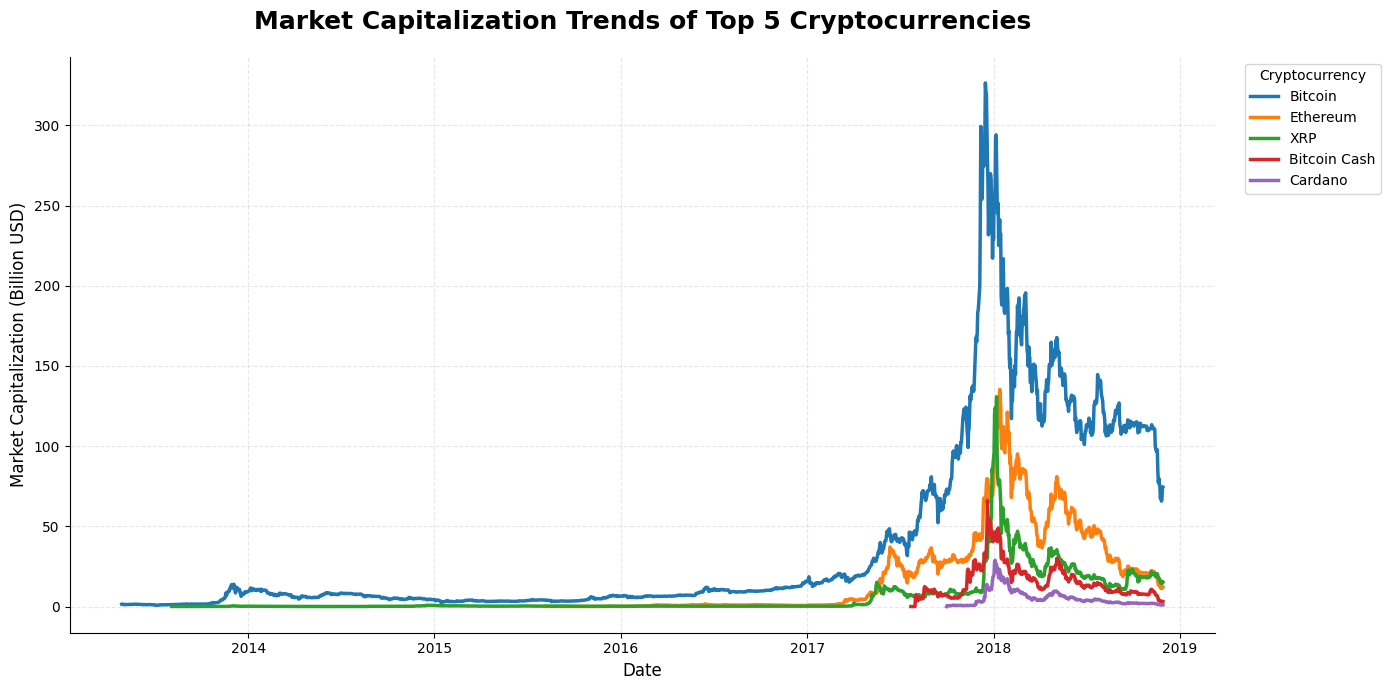

In [61]:
top5 = (
    crypto.groupby('name')['market']
          .max()
          .nlargest(5)
          .index
)

plt.figure(figsize=(14,7))

for coin in top5:
    temp = crypto[crypto['name'] == coin]

    plt.plot(
        temp['date'],
        temp['market'] / 1e9,
        linewidth=2.5,
        label=coin
    )

plt.title(
    'Market Capitalization Trends of Top 5 Cryptocurrencies',
    fontsize=18,
    fontweight='bold',
    pad=20
)

plt.xlabel('Date', fontsize=12)
plt.ylabel('Market Capitalization (Billion USD)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.3)

plt.legend(
    title='Cryptocurrency',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

sns.despine()

plt.tight_layout()
plt.show()

# Key Insights
**1. A strong positive correlation (0.88) was observed between market capitalization and trading volume, indicating that larger cryptocurrencies generally attract higher trading activity.**

**2. Closing price and price spread showed a strong positive relationship (0.75), suggesting that higher-priced cryptocurrencies tend to experience larger daily price fluctuations.**

**3. Statistical testing revealed that cryptocurrency daily returns do not follow a normal distribution (p-value < 0.05), highlighting the presence of extreme market movements and higher market uncertainty.**

**4. Z-score analysis identified only 18 extreme return events, indicating that unusually large price movements were relatively rare within the selected top cryptocurrencies.**

**5. The cryptocurrency market experienced its strongest bullish phase in 2017, recording significantly higher average returns than any other year in the dataset.**

**6. Market performance weakened considerably in 2018, reflecting a major correction following the exceptional growth observed in 2017.**

**7. Volatility analysis showed noticeable differences in risk levels among the top cryptocurrencies, demonstrating that not all digital assets exhibit the same market behavior.**

**8. Most daily returns were concentrated around zero, while the distribution exhibited heavy tails, indicating occasional extreme gains and losses.**

**9. The top cryptocurrencies dominated market capitalization, reflecting a highly concentrated market structure where a small number of assets account for a large share of total market value.**

**10. Market capitalization trends revealed sustained long-term growth among leading cryptocurrencies despite periods of elevated volatility and market corrections.**

# Conclusion

**This project analyzed the performance and market behavior of the top 20 cryptocurrencies using historical price, volume, and market capitalization data. The analysis focused on price trends, volatility, returns, market capitalization growth, and statistical characteristics of cryptocurrency returns.**

**The findings revealed a strong relationship between market capitalization and trading volume, while return distributions showed significant deviations from normality, highlighting the highly volatile nature of the cryptocurrency market. Volatility and return analysis identified substantial differences in risk levels across cryptocurrencies, and statistical testing confirmed the presence of extreme market events. The study also identified 2017 as the strongest bullish period in the dataset, followed by a significant market correction in 2018.**

**Overall, the project demonstrates that cryptocurrency markets are highly dynamic, characterized by rapid growth phases, elevated volatility, and occasional extreme price movements. These insights can help investors, analysts, and researchers better understand market behavior and risk within the cryptocurrency ecosystem.**